In [1]:
#import os
import datetime
import numpy as np
import pandas as pd
import joblib

from t_tech.invest import Client, CandleInterval
from t_tech.invest.utils import quotation_to_decimal

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from catboost import CatBoostRegressor

import config

pd.set_option('display.max_columns', 50)

In [2]:
#pip install t-tech-investments

In [3]:
# Константы (сохранить в конфиг)
interval_dict = {'1M': CandleInterval.CANDLE_INTERVAL_1_MIN,
                 '5M': CandleInterval.CANDLE_INTERVAL_5_MIN,
                 '15M': CandleInterval.CANDLE_INTERVAL_15_MIN,
                 '30M': CandleInterval.CANDLE_INTERVAL_30_MIN,
                 '1H': CandleInterval.CANDLE_INTERVAL_HOUR,
                 '1d': CandleInterval.CANDLE_INTERVAL_DAY,
                 '1w': CandleInterval.CANDLE_INTERVAL_WEEK,
                 '1m': CandleInterval.CANDLE_INTERVAL_MONTH,
                 }

calendar_dict = {'month': 12,
                 'day_of_week': 7,
                 'hour': 24,
                 'minute': 60}

In [4]:
TBANK_INVEST_TOKEN = config.TBANK_INVEST_TOKEN

### Загрузка данных

In [5]:
#Загрузка валют
def get_currencies():
    with Client(TBANK_INVEST_TOKEN) as client:
        currencies = client.instruments.currencies()

        data = []
        for currency in currencies.instruments:
            data.append({'name': currency.name,
                         'figi': currency.figi,
                         'ticker': currency.ticker,
                         'currency': currency.currency,
                         'lot': currency.lot,
                         'nominal': quotation_to_decimal(currency.nominal),
                         'min_price_increment': quotation_to_decimal(currency.min_price_increment), #шаг цены
                         'first_1day_candle_date': currency.first_1day_candle_date,
                         'api_trade_available_flag': currency.api_trade_available_flag,
                         'buy_available_flag': currency.buy_available_flag})          
        df_currency = pd.DataFrame(data)
        df_currency['first_1day_candle_date'] = df_currency['first_1day_candle_date'].dt.tz_localize(None) #явно приводим дату+время к UTC+0
        
        return df_currency
df_currency = get_currencies()
df_currency.head(3)

,name,figi,ticker,currency,lot,nominal,min_price_increment,first_1day_candle_date,api_trade_available_flag,buy_available_flag
0,Китайский юань,CNY000TODTOM,CNYRUBTODTOM,rub,100000,1.00000000,0.00001000,2018-03-12 07:00:00,True,True
1,Киргизский сом,BBG0013J7Y00,KGSRUB_TOM,rub,1000,100.00000000,0.00250000,2022-11-03 07:00:00,True,True
2,Узбекский сум,BBG0013HQ310,UZSRUB_TOM,rub,1000000,10000.00000000,0.00250000,2022-09-12 07:00:00,True,True


In [6]:
df_currency[df_currency['name'] == 'Золото']

,name,figi,ticker,currency,lot,nominal,min_price_increment,first_1day_candle_date,api_trade_available_flag,buy_available_flag
5,Золото,BBG000VJ5YR4,GLDRUB_TOM,rub,1,1.00000000,0.10000000,2018-03-07 07:00:00,True,True


In [7]:
#Загрузка исторических данных
def get_all_candles(figi, 
                    start_date, end_date, interval):
    with Client(TBANK_INVEST_TOKEN) as client:
        candles = client.get_all_candles(figi=figi,
                                         from_=start_date, 
                                         to=end_date, 
                                         interval=interval
                                         )

        data = []
        for candle in candles:
            data.append({'time': candle.time,
                         'volume': candle.volume,
                         #'open': float(quotation_to_decimal(candle.open)),
                         #'high': float(quotation_to_decimal(candle.high)),
                         #'low': float(quotation_to_decimal(candle.low)),
                         'close': float(quotation_to_decimal(candle.close)),
                         'is_complete': candle.is_complete
                         })
        df_candle = pd.DataFrame(data)
        df_candle['time'] = df_candle['time'].dt.tz_localize(None) 
        df_candle = df_candle[df_candle['is_complete'] == True].reset_index(drop=True) #рассматриваем только завершенные свечи за выбранный промежуток
        
        df_candle = df_candle[['time', 'volume', 'close']]
        return df_candle[['time', 'volume', 'close']]

figi = 'BBG000VJ5YR4'
start_date = pd.to_datetime('2019-01-01') #Дату указываем в формате UTC+0
end_date = pd.to_datetime('2026-01-01') #UTC
interval = interval_dict['1m']
df_candle = get_all_candles(figi, 
                            start_date, end_date, interval)
df_candle.head(3)

,time,volume,close
0,2019-01-01,26405,2780.0
1,2019-02-01,60285,2791.5
2,2019-03-01,43677,2711.0


### Первичный анализ данных

In [8]:
df_candle_analysis = df_candle.copy()
df_candle_analysis.head(3)

,time,volume,close
0,2019-01-01,26405,2780.0
1,2019-02-01,60285,2791.5
2,2019-03-01,43677,2711.0


In [9]:
df_candle_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    84 non-null     datetime64[ns]
 1   volume  84 non-null     int64         
 2   close   84 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 2.1 KB


<Axes: xlabel='time'>

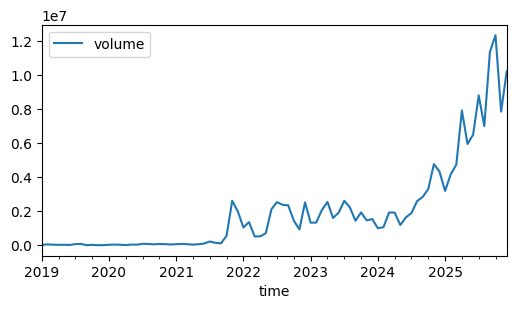

In [10]:
df_candle_analysis.plot(x='time', y='volume', figsize=(6, 3))

<Axes: xlabel='time'>

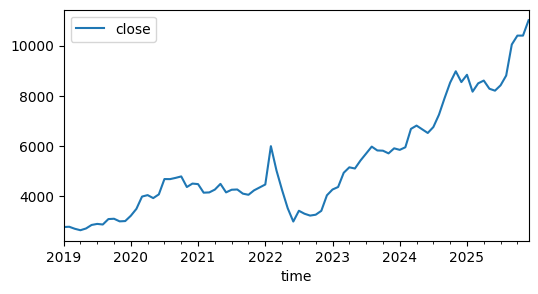

In [11]:
df_candle_analysis.plot(x='time', y='close', figsize=(6, 3))

count    83.000000
mean      1.019375
std       0.074531
min       0.830551
25%       0.985272
50%       1.017599
75%       1.049512
max       1.341232
Name: close_ratio, dtype: float64


<Axes: xlabel='time'>

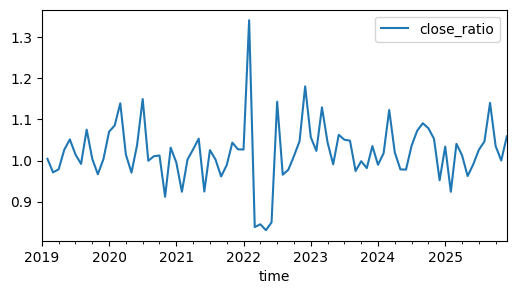

In [12]:
df_candle_analysis['close_lag_1'] = df_candle_analysis['close'].shift(1)
df_candle_analysis['close_ratio'] = df_candle_analysis['close']/df_candle_analysis['close_lag_1']
print(df_candle_analysis['close_ratio'].describe())
df_candle_analysis.plot(x='time', y='close_ratio', figsize=(6, 3))

count    83.000000
mean      1.247555
std       0.780193
min       0.128213
25%       0.762172
50%       1.086189
75%       1.365617
max       4.707168
Name: volume_ratio, dtype: float64


<Axes: xlabel='time'>

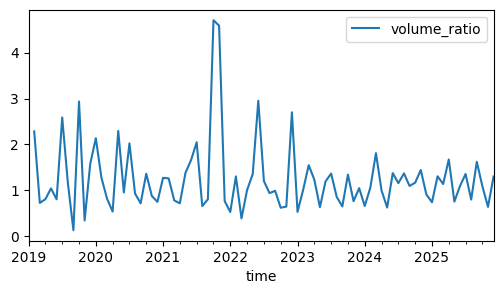

In [13]:
df_candle_analysis['volume_lag_1'] = df_candle_analysis['volume'].shift(1)
df_candle_analysis['volume_ratio'] = df_candle_analysis['volume'] / df_candle_analysis['volume_lag_1']
print(df_candle_analysis['volume_ratio'].describe())
df_candle_analysis.plot(x='time', y='volume_ratio', figsize=(6, 3))

count      83.000000
mean       99.179518
std       379.389943
min      -969.990000
25%       -67.365000
50%       100.480000
75%       255.505000
max      1526.500000
Name: diff, dtype: float64


<Axes: xlabel='time'>

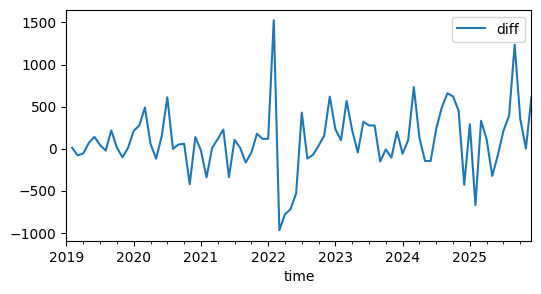

In [14]:
df_candle_analysis['close_lag_1'] = df_candle_analysis['close'].shift(1)
df_candle_analysis['diff'] = df_candle_analysis['close'] - df_candle_analysis['close_lag_1']
print(df_candle_analysis['diff'].describe())
df_candle_analysis.plot(x='time', y='diff', figsize=(6, 3))

### Обработка аномальных значений (опционально)

**Аномальными значениями** будем считать случаи, когда отношение текущего и предыдущего значения расходятся установленного *порога*.
*Пороговое значение* установим с помощью **квартилей**: 5 и 95.

Например, имеем значения:  
[1, 10, 11, 15, 100, 110, 113, 123].  

Их отношения составит:  
[None, 10/1, 11/10, 15/11, 100/15, 110/100, 113/110, 123/113] или [None, 10, 1.1, 1.36, 6.66, 1.1, 1.03, 1.08].  

5-ый квартиль = 1.045  
95-ый квартиль = 9.000 

Аномальные значения, которые ниже 5-го или выше 95-го квартиля, будут изменены до порогового значения.  
Итого, после обратного преобразования, получим обновленные значения:  
[None, 9, 1.1, 1.36, 6.66, 1.1, 1.03, 1.08] --> [1, 9, 11, 15, 100, 110, 113, 123] 

### Подготовка признаков

В качестве признаков используем:
- календарные признаки (месяц, день недели, час, минута);
- лаги (целового значения и объема сделок);
- скользящее среднее (относительно целового значения).

Таргетами служат лиды (leads).

In [15]:
def feature_target_split(df_candle, target,
                         lags=[1, 2, 3], #, 7, 14, 30],
                         window_sizes=[3] #, 7, 30]
                         ):
    
    #подготовка признаков
    df_candle_feature = df_candle.copy()
    
    #календарные признаки
    df_candle_feature['month'] = df_candle_feature['time'].dt.month - 1 #1-12 → 0-11
    #df_candle_feature['day_of_week'] = df_candle_feature['time'].dt.dayofweek
    #df_candle_feature['hour'] = df_candle_feature['time'].dt.hour
    #df_candle_feature['minute'] = df_candle_feature['time'].dt.minute
    
    #лаги
    lag_prev = 0
    for lag in lags:
        df_candle_feature[f'volume_lag_{lag}'] = df_candle_feature['volume'].shift(lag)
        df_candle_feature[f'{target}_lag_{lag}'] = df_candle_feature[target].shift(lag)
        if lag_prev != 0:
            df_candle_feature[f'volume_lag_diff_{lag}'] = df_candle_feature[f'volume_lag_{lag_prev}'] - df_candle_feature[f'volume_lag_{lag}']
            df_candle_feature[f'{target}_lag_diff_{lag}'] = df_candle_feature[f'{target}_lag_{lag_prev}'] - df_candle_feature[f'{target}_lag_{lag}']
        lag_prev = lag
        
    #скользящее среднее
    #window_sizes = [3] #, 7, 30]
    for window in window_sizes:
        df_candle_feature[f'{target}_rolling_mean_{window}'] = df_candle_feature[target].shift(1).rolling(window).mean()
        df_candle_feature[f'{target}_rolling_std_{window}'] = df_candle_feature[target].shift(1).rolling(window).std()
        
    #лиды (горизонт прогноза)
    #leads = [0] #, 1, 2, 3, 4, 5, 6, 7] #[i for i in range(8)]
    #for l in leads:
        #df_candle_feature[f'{target}_lead_{l}'] = df_candle_feature[target].shift(-l)
        
    #числовой ряд
    df_candle_feature = df_candle_feature.dropna().reset_index(drop=True)
    df_candle_feature['time_ind'] = df_candle_feature.index

    
    #подготовка таргета (после того как подготовили и очистили признаки от Null значений)
    df_candle_target = df_candle_feature[['time', target]].copy()
   
    #обновляем индексы
    df_candle_feature.index = df_candle_feature['time']
    df_candle_target.index = df_candle_target['time']
    
    #удаляем лишние поля
    df_candle_feature = df_candle_feature.drop(columns=['time', 'volume', target])
    df_candle_target = df_candle_target.drop(columns=['time'])
    
    return df_candle_feature, df_candle_target

target = 'close'
df_candle_feature, df_candle_target = feature_target_split(df_candle, target)
print(f'Количество признаков: {df_candle_feature.shape[1]}')
print(f'Количество записей: {df_candle_target.shape[0]}')
df_candle_feature.head(3)

Количество признаков: 14
Количество записей: 81


,month,volume_lag_1,close_lag_1,volume_lag_2,close_lag_2,volume_lag_diff_2,close_lag_diff_2,volume_lag_3,close_lag_3,volume_lag_diff_3,close_lag_diff_3,close_rolling_mean_3,close_rolling_std_3,time_ind
time,,,,,,,,,,,,,,
2019-04-01,3,43677.0,2711.0,60285.0,2791.5,-16608.0,-80.5,26405.0,2780.0,33880.0,11.5,2760.833333,43.538297,0
2019-05-01,4,35150.0,2653.5,43677.0,2711.0,-8527.0,-57.5,60285.0,2791.5,-16608.0,-80.5,2718.666667,69.318708,1
2019-06-01,5,36572.0,2723.0,35150.0,2653.5,1422.0,69.5,43677.0,2711.0,-8527.0,-57.5,2695.833333,37.149473,2


In [16]:
#обозначим таргет (целевое значение) и оставим только нужные признаки
#target = 'close'
targets = ['close_0'] #случаи, когда нужно будет предсказывать несколько значений подряд
calendar_features = ['month'] #'day_of_week', 'hour', 'minute',]
numeric_features = ['time_ind',
                    f'{target}_lag_1', #f'{target}_lag_2', f'{target}_lag_3', #f'{target}_lag_7', f'{target}_lag_14', f'{target}_lag_30',
                    #'volume_lag_1', 'volume_lag_2', 'volume_lag_3', #'volume_lag_7', 'volume_lag_14', 'volume_lag_30',
                    #f'{target}_lag_diff_2', f'{target}_lag_diff_3', #f'{target}_lag_diff_7', f'{target}_lag_diff_14', f'{target}_lag_diff_30',
                    #'volume_lag_diff_2', 'volume_lag_diff_3', #'volume_lag_diff_7', 'volume_lag_diff_14', 'volume_lag_diff_30',
                    #f'{target}_rolling_mean_3', #f'{target}_rolling_mean_7', f'{target}_rolling_mean_30'
                    #f'{target}_rolling_std_3', #f'{target}_rolling_std_7', f'{target}_rolling_std_30'
                    ]
features = calendar_features + numeric_features
len(features)

3

In [17]:
df_candle_feature

,month,volume_lag_1,close_lag_1,volume_lag_2,close_lag_2,volume_lag_diff_2,close_lag_diff_2,volume_lag_3,close_lag_3,volume_lag_diff_3,close_lag_diff_3,close_rolling_mean_3,close_rolling_std_3,time_ind
time,,,,,,,,,,,,,,
2019-04-01,3,43677.0,2711.0,60285.0,2791.5,-16608.0,-80.5,26405.0,2780.0,33880.0,11.5,2760.833333,43.538297,0
2019-05-01,4,35150.0,2653.5,43677.0,2711.0,-8527.0,-57.5,60285.0,2791.5,-16608.0,-80.5,2718.666667,69.318708,1
2019-06-01,5,36572.0,2723.0,35150.0,2653.5,1422.0,69.5,43677.0,2711.0,-8527.0,-57.5,2695.833333,37.149473,2
2019-07-01,6,29339.0,2863.0,36572.0,2723.0,-7233.0,140.0,35150.0,2653.5,1422.0,69.5,2746.500000,106.708716,3
2019-08-01,7,75928.0,2905.0,29339.0,2863.0,46589.0,42.0,36572.0,2723.0,-7233.0,140.0,2830.333333,95.296030,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,7,8785152.0,8421.1,6484107.0,8208.0,2301045.0,213.1,5941851.0,8285.8,542256.0,-77.8,8304.966667,107.835167,76
2025-09-01,8,6993115.0,8810.2,8785152.0,8421.1,-1792037.0,389.1,6484107.0,8208.0,2301045.0,213.1,8479.766667,305.356420,77
2025-10-01,9,11335941.0,10046.0,6993115.0,8810.2,4342826.0,1235.8,8785152.0,8421.1,-1792037.0,389.1,9092.433333,848.420146,78


In [18]:
df_candle_feature = df_candle_feature[features].copy()

### Разбивка датасетов

Делим общий датасет на обучающую и тестовую выборки. 

In [19]:
def train_train_split(df_candle_feature, df_candle_target,
                      start_date_train, end_date_train,
                      start_date_test, end_date_test):
    df_candle_feature_train = df_candle_feature[start_date_train:end_date_train].copy()
    df_candle_target_train = df_candle_target[start_date_train:end_date_train].copy()
    
    df_candle_feature_test = df_candle_feature[start_date_test:end_date_test].copy()
    df_candle_target_test = df_candle_target[start_date_test:end_date_test].copy()

    return df_candle_feature_train, df_candle_target_train, df_candle_feature_test, df_candle_target_test

start_date_train = '2022-10-01'
end_date_train = '2025-09-01'
start_date_test = '2025-10-01'
end_date_test = '2025-12-01'
df_candle_feature_train, df_candle_target_train, df_candle_feature_test, df_candle_target_test = train_train_split(df_candle_feature, df_candle_target,
                                                                                                                   start_date_train, end_date_train,
                                                                                                                   start_date_test, end_date_test)
print(f'Кол-во строк в тестовой выборке: {df_candle_feature_test.shape[0]}')
print(f'Кол-во строк в обучающей выборке: {df_candle_feature_train.shape[0]}')
print(f'Доля тестовой выборки: {round(df_candle_feature_test.shape[0] / (df_candle_feature_test.shape[0] + df_candle_feature_train.shape[0]) * 100, 2)}%')

Кол-во строк в тестовой выборке: 3
Кол-во строк в обучающей выборке: 36
Доля тестовой выборки: 7.69%


### Масштабирование данных

Для календарных признаков используем ***Циклическое масштабирование***, а для всех остальных - ***StandardScaler***.

***Циклическое масштабирование***.

*Прямое преобразование*:  
x_encode_sin = sin(2π * X / period)  
x_encode_cos = cos(2π * X / period)

*Обратное*:  
x_decode = arctan2(x_encode_sin, x_encode_cos) * period / (2π)  
x_decode = x_decode % period  # избавляемся от отрицательных значений  
x_decode = x_decode.round() #округление до целого

In [20]:
def calendar_encoding(df_candle_, calendar_features, calendar_dict):
    df_candle_encode = df_candle_[calendar_features].copy()
    
    for feature in calendar_features:
        df_candle_encode[f'{feature}_encode_sin'] = np.sin(2 * np.pi * df_candle_encode[f'{feature}'] / calendar_dict[f'{feature}'])
        df_candle_encode[f'{feature}_encode_cos'] = np.cos(2 * np.pi * df_candle_encode[f'{feature}'] / calendar_dict[f'{feature}'])
           
    df_candle_encode = df_candle_encode.drop(columns=calendar_features)
    return df_candle_encode

In [21]:
df_candle_feature_train_calendar_encode = calendar_encoding(df_candle_feature_train, calendar_features, calendar_dict)
df_candle_feature_test_calendar_encode = calendar_encoding(df_candle_feature_test, calendar_features, calendar_dict)
df_candle_feature_train_calendar_encode.head(3)

,month_encode_sin,month_encode_cos
time,,
2022-10-01,-1.000000,-1.836970e-16
2022-11-01,-0.866025,5.000000e-01
2022-12-01,-0.500000,8.660254e-01


***StandardScaler***.

*Прямое преобразование*:  
x_encode = (X - mean) / std  

*Обратное*:  
x_decode = x_encode * std + mean

Чтобы провести стандартизацию данных, нужно сначала ее обучить на обучаюшей выборке и сохранить в отдельный файл (чтобы потом ее применить на обучающей и тестовой выборках).

In [22]:
def standard_scaler_fit_save(df_candle_,
                             start_date_train, end_date_train,
                             numeric_fields=['close'],
                             target=False):
    standard_scaler = StandardScaler()
    standard_scaler.fit(df_candle_[numeric_fields])
    if target == False:
        joblib.dump(standard_scaler, f'standard_scaler_feature_train_{start_date_train}_{end_date_train}.joblib')
    else:
        joblib.dump(standard_scaler, f'standard_scaler_target_train_{start_date_train}_{end_date_train}.joblib')

standard_scaler_fit_save(df_candle_feature_train,
                         start_date_train, end_date_train,
                         numeric_fields=numeric_features,
                         target=False)

standard_scaler_fit_save(df_candle_target_train,
                         start_date_train, end_date_train,
                         numeric_fields=['close'],
                         target=True)

In [23]:
def numeric_encoding(df_candle_,
                     start_date_train, end_date_train,
                     numeric_fields,
                     target=False):
    if target == False:
        standard_scaler = joblib.load(f'standard_scaler_feature_train_{start_date_train}_{end_date_train}.joblib')
    else:
        standard_scaler = joblib.load(f'standard_scaler_target_train_{start_date_train}_{end_date_train}.joblib')
    
    df_candle_numeric_encode = pd.DataFrame(standard_scaler.transform(df_candle_[numeric_fields]),
                                            columns=numeric_fields,
                                            index=df_candle_.index)
    
    return df_candle_numeric_encode

In [24]:
def numeric_decoding(df_candle_,
                     start_date_train, end_date_train,
                     numeric_fields=['close'],
                     target=True):
    if target == False:
        standard_scaler = joblib.load(f'standard_scaler_feature_train_{start_date_train}_{end_date_train}.joblib')
    else:
        standard_scaler = joblib.load(f'standard_scaler_target_train_{start_date_train}_{end_date_train}.joblib')

    df_candle_numeric_decode = pd.DataFrame(standard_scaler.inverse_transform(df_candle_[numeric_fields]),
                                            columns=numeric_fields,
                                            index=df_candle_.index)
    
    return df_candle_numeric_decode

In [25]:
df_candle_feature_train_numeric_encode = numeric_encoding(df_candle_feature_train,
                                                          start_date_train, end_date_train,
                                                          numeric_fields=numeric_features,
                                                          target=False)
df_candle_feature_test_numeric_encode = numeric_encoding(df_candle_feature_test,
                                                         start_date_train, end_date_train,
                                                         numeric_fields=numeric_features,
                                                         target=False)

df_candle_target_train_numeric_encode = numeric_encoding(df_candle_target_train,
                                                         start_date_train, end_date_train,
                                                         numeric_fields=['close'],
                                                         target=True)
df_candle_target_test_numeric_encode = numeric_encoding(df_candle_target_test,
                                                        start_date_train, end_date_train,
                                                        numeric_fields=['close'],
                                                        target=True)

In [26]:
df_candle_feature_train_numeric_encode.head(3)

,time_ind,close_lag_1
time,,
2022-10-01,-1.684588,-1.879479
2022-11-01,-1.588326,-1.859073
2022-12-01,-1.492064,-1.769287


In [27]:
#df_candle_feature_train_encode = pd.concat([df_candle_feature_train_calendar_encode, df_candle_feature_train_numeric_encode], axis=1)
#df_candle_feature_test_encode = pd.concat([df_candle_feature_test_calendar_encode, df_candle_feature_test_numeric_encode], axis=1)

df_candle_feature_train_encode = df_candle_feature_train_numeric_encode.copy()
df_candle_feature_test_encode = df_candle_feature_test_numeric_encode.copy()

df_candle_target_train_encode = df_candle_target_train_numeric_encode.copy()
df_candle_target_test_encode = df_candle_target_test_numeric_encode.copy()

In [28]:
df_candle_feature_train_encode.head(3)

,time_ind,close_lag_1
time,,
2022-10-01,-1.684588,-1.879479
2022-11-01,-1.588326,-1.859073
2022-12-01,-1.492064,-1.769287


In [29]:
numeric_decoding(df_candle_target_test_encode,
                 start_date_train, end_date_train,
                 numeric_fields=['close'],
                 target=True)

,close
time,
2025-10-01,10399.0
2025-11-01,10400.0
2025-12-01,11011.9


### Модели

#### Catboost

In [30]:
def catboost_model_fit_save(df_candle_feature_train_encode, df_candle_target_train_encode,
                            start_date_train, end_date_train, 
                            hyperparams, 
                            verbose=100):
    catboost_model = CatBoostRegressor(loss_function='MAE',
                                       verbose=verbose, random_state=27,
                                       **hyperparams,
                                       )
    catboost_model.fit(df_candle_feature_train_encode, df_candle_target_train_encode)
    catboost_model.save_model(f'catboost_model_{start_date_train}_{end_date_train}.cbm')

In [31]:
hyperparams = {'iterations': 1000,
               'learning_rate': 0.03,
               'depth': 4
               }
catboost_model_fit_save(df_candle_feature_train_encode, df_candle_target_train_encode,
                        start_date_train, end_date_train, 
                        hyperparams, 
                        verbose=200)

0:	learn: 0.8247646	total: 103ms	remaining: 1m 43s
200:	learn: 0.0709741	total: 180ms	remaining: 716ms
400:	learn: 0.0459215	total: 255ms	remaining: 380ms
600:	learn: 0.0275585	total: 328ms	remaining: 218ms
800:	learn: 0.0229407	total: 401ms	remaining: 99.7ms
999:	learn: 0.0209082	total: 482ms	remaining: 0us


In [32]:
def catboost_model_predict(df_candle_feature_,
                           start_date_train, end_date_train,
                           numeric_fields=['close'],
                           target=True):
    catboost_model = CatBoostRegressor()
    catboost_model.load_model(f'catboost_model_{start_date_train}_{end_date_train}.cbm')
    df_candle_predict_train_encode = pd.DataFrame(catboost_model.predict(df_candle_feature_), 
                                                  columns=numeric_fields,
                                                  index=df_candle_feature_.index)
    
    df_candle_predict_train_decode = numeric_decoding(df_candle_predict_train_encode,
                                                      start_date_train, end_date_train,
                                                      numeric_fields=numeric_fields,
                                                      target=target)
    return df_candle_predict_train_decode

In [33]:
df_candle_predict_train_decode = catboost_model_predict(df_candle_feature_train_encode, start_date_train, end_date_train)
df_candle_predict_test_decode = catboost_model_predict(df_candle_feature_test_encode, start_date_train, end_date_train)

### Оценка модели

In [34]:
def model_scores(df_candle_target_, df_candle_predict_,
                 model_name='catboost_model', suffix=''):
    mae = round(mean_absolute_error(df_candle_target_, df_candle_predict_), 4)
    rmse = round(root_mean_squared_error(df_candle_target_, df_candle_predict_), 4)

    df = pd.DataFrame([[model_name, mae, rmse]], columns=['model_name', f'mae{suffix}', f'rmse{suffix}'])
    return df

In [35]:
model_scores(df_candle_target_train, df_candle_predict_train_decode,
             model_name='catboost_model', suffix='_train')

,model_name,mae_train,rmse_train
0,catboost_model,36.0628,92.6922


In [36]:
model_scores(df_candle_target_test, df_candle_predict_test_decode,
             model_name='catboost_model', suffix='_test')

,model_name,mae_test,rmse_test
0,catboost_model,1569.0485,1595.3853


In [37]:
df_candle_predict = pd.concat([df_candle_predict_train_decode, df_candle_predict_test_decode])
df_candle_predict.columns = ['close_predict']

In [38]:
df_candle_fact = df_candle[['time', 'close']].copy()
df_candle_fact.index = df_candle['time']
df_candle_fact = df_candle_fact[['close']]

<Axes: xlabel='time'>

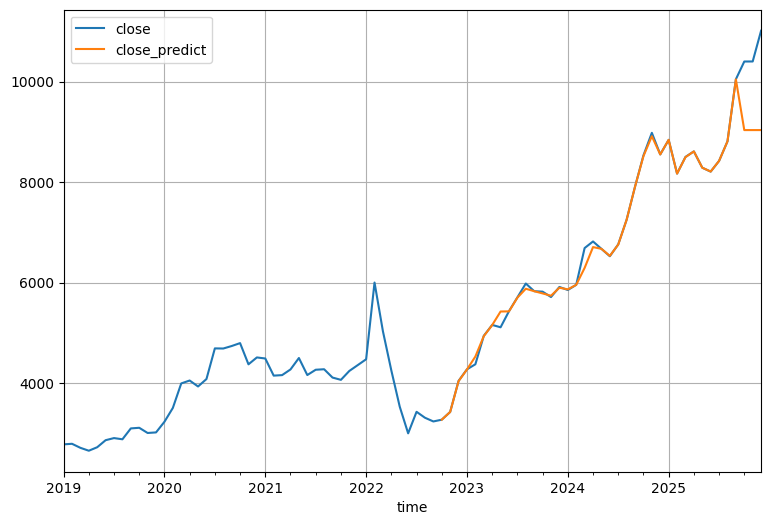

In [39]:
df_candle_fact_predict = pd.concat([df_candle_fact, df_candle_predict], axis=1)
df_candle_fact_predict.plot(figsize=(9, 6), grid=True)

In [40]:
df_candle_fact_predict.tail(5)

,close,close_predict
time,,
2025-08-01,8810.2,8810.171211
2025-09-01,10046.0,10043.273341
2025-10-01,10399.0,9034.584803
2025-11-01,10400.0,9034.584803
2025-12-01,11011.9,9034.584803


In [41]:
catboost_model = CatBoostRegressor()
catboost_model.load_model(f'catboost_model_{start_date_train}_{end_date_train}.cbm')
catboost_model.get_feature_importance()

array([54.21521862, 45.78478138])

In [42]:
catboost_model = CatBoostRegressor()
catboost_model.load_model(f'catboost_model_{start_date_train}_{end_date_train}.cbm')
importance = catboost_model.get_feature_importance()

features = df_candle_feature_train_encode.columns.tolist()
sorted_feature_importance = sorted(zip(features, importance), key=lambda x: x[1], reverse=True)
for feature, score in sorted_feature_importance:
    print(f"{feature}: {round(score, 1)}")

time_ind: 54.2
close_lag_1: 45.8
